In [24]:
import numpy as np
import matplotlib.pyplot as plt

#define the sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [23]:
#loss function:log likelihood
def compute_loss(y,hx):
    return -np.mean(y*np.log(hx)+(1-y)*np.log(1-hx))


In [22]:
#gradient of the loss
def compute_gradient(x,y,hx):
    return np.dot(x.T, (hx-y))/y.shape[0]

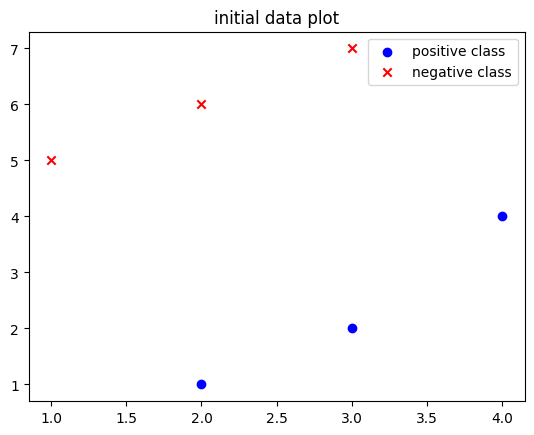

In [21]:
#dataset
X=np.array([
    [2,1],
    [3,2],
    [4,4], #Positive values
    [1,5],
    [2,6],
    [3,7]  #Negative values
])
y=np.array([1,1,1,0,0,0])#labels

#plot initial data
plt.scatter(X[:3,0], X[:3,1], color='blue', marker='o',label='positive class')
plt.scatter(X[3:,0], X[3:,1], color='red' , marker='x', label='negative class')
plt.xlabel=('whisker length')
plt.ylabel=('Ear flappiness index')
plt.legend()
plt.title('initial data plot')
plt.show()

In [27]:
#LOGISTIC REGRESSION MODEL
def logistic_regression(x,y,learning_rate=0.1, num_iterations=10):
    #add intercept term to x
    x=np.hstack((np.ones((x.shape[0],1)),x))

    #initialize weights
    weights=np.zeros(x.shape[1])

    #gradient descent
    for i in range (num_iterations):
        z=np.dot(x, weights)
        hx=sigmoid(z)
        loss=compute_loss(y,hx)
        gradient= compute_gradient(x,y,hx)
        weights-=learning_rate*gradient

        if i%1==0:
             plot_decision_boundary(x,y,weights,loss,i)
             print(f'Iteration{i}:Theta={weights},Loss={loss}')




    return weights



In [28]:
# plotting function for decision boundary
def plot_decision_boundary(x,y,weights,iterations,loss):
    plt.scatter(x[:3,1],x[:3,2], color='blue', marker='o', label='positive class'if iterations==0 else"")
    plt.scatter(x[3:,1], x[3:,2], color='red', marker='x',label='negative class'if iterations==0 else"")
    
    #extend the values a little bit beyond the minimum and maximum values of the dataset
    x_values=np.array([np.min(x[:,1])-1, np.max(x[:,1])+1])
    y_values=-(weights[0]+weights[1]*x_values)/weights[2]
    plt.plot(x_values,y_values,"k")

    plt.xlim(x_values[0], x_values[1])
    plt.ylim(np.min(x[:,2])-1,np.max(x[:,2])+1)
    plt.xlabel=('whisker length')
    plt.ylabel=('ear flappiness index')
    plt.title(f"Decision boundary at iteration{iterations}/nLoss:{loss}")
    if iterations==0:
     plt.legend()


    plt.show()


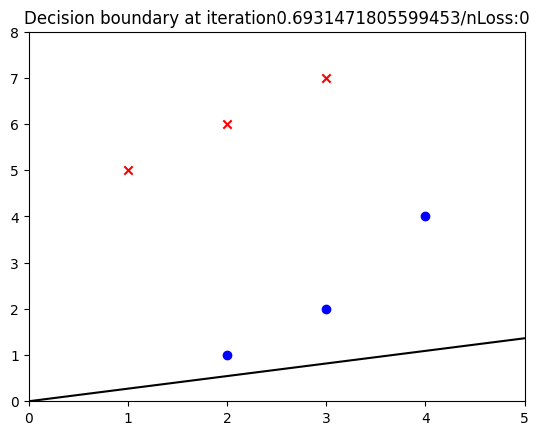

Iteration0:Theta=[ 0.          0.025      -0.09166667],Loss=0.6931471805599453


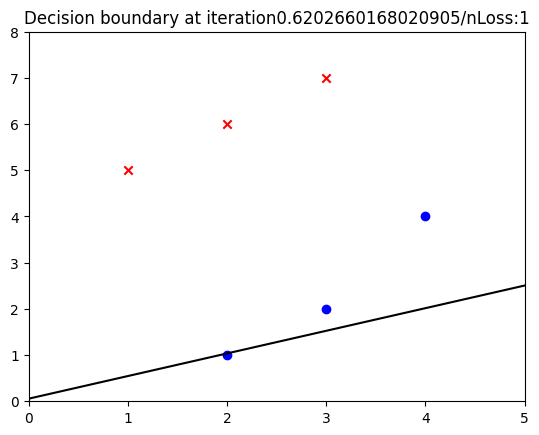

Iteration1:Theta=[ 0.00784781  0.06887779 -0.14060525],Loss=0.6202660168020905


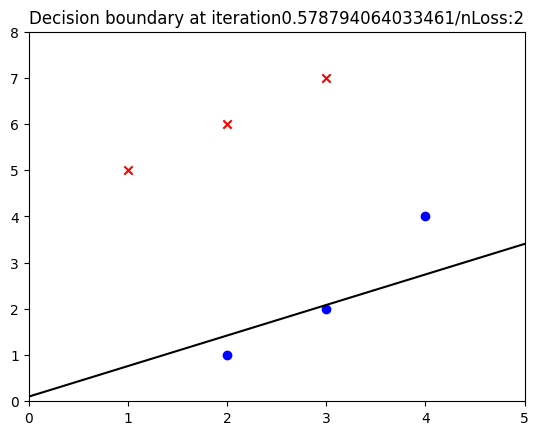

Iteration2:Theta=[ 0.01764134  0.11658362 -0.17629863],Loss=0.578794064033461


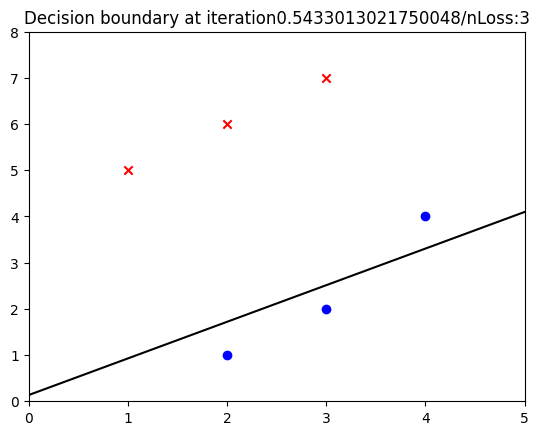

Iteration3:Theta=[ 0.02775584  0.16401158 -0.20689154],Loss=0.5433013021750048


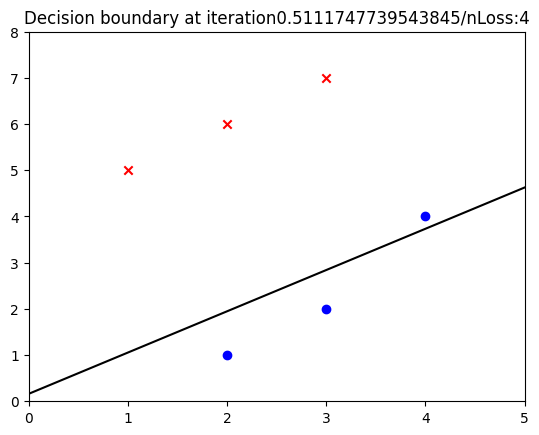

Iteration4:Theta=[ 0.03768945  0.20992896 -0.23499581],Loss=0.5111747739543845


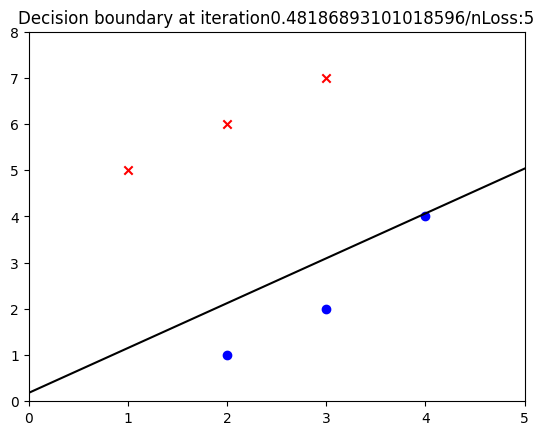

Iteration5:Theta=[ 0.04728565  0.25399034 -0.26154053],Loss=0.48186893101018596


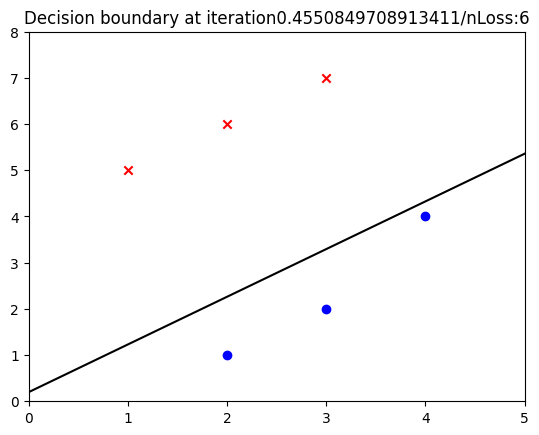

Iteration6:Theta=[ 0.0565048   0.29615111 -0.28688777],Loss=0.4550849708913411


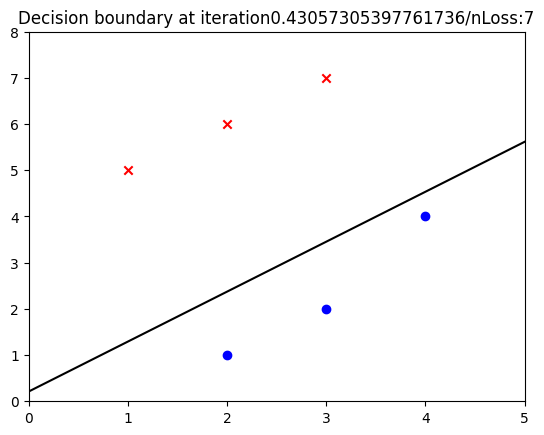

Iteration7:Theta=[ 0.06534809  0.33647087 -0.31119923],Loss=0.43057305397761736


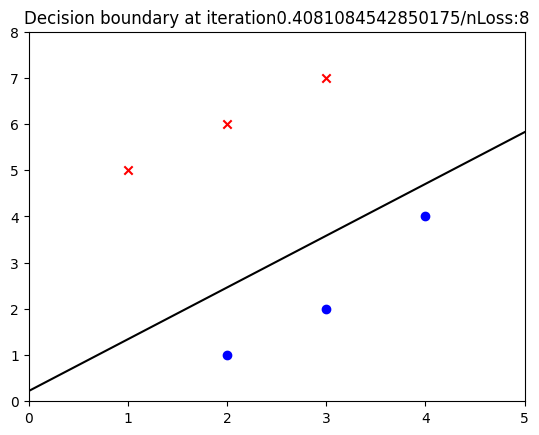

Iteration8:Theta=[ 0.07383072  0.37504349 -0.3345636 ],Loss=0.4081084542850175


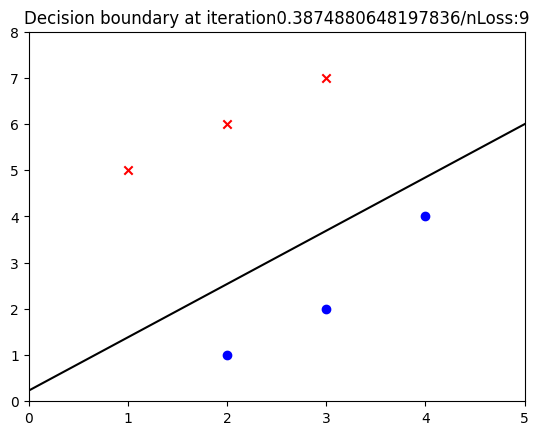

Iteration9:Theta=[ 0.08197221  0.41197135 -0.35704216],Loss=0.3874880648197836


In [29]:
#training the model 
weights= logistic_regression(X,y)